# EDA — Actividad, concentración y estructura de la oferta Airbnb

Este notebook estudia **220.031 anuncios en seis ciudades** para responder cuatro preguntas:

1. ¿Cómo se relacionan el volumen de oferta y la actividad relativa por barrio?
2. ¿Qué grado de concentración presentan las reseñas acumuladas?
3. ¿Cómo se distribuyen los anuncios según el tamaño de cartera observado del anfitrión?
4. ¿Qué diferencias aparecen entre ciudades en actividad, concentración y dispersión geográfica?

El análisis usa reseñas como **proxy de actividad observada**. No mide reservas, ocupación, demanda insatisfecha, rentabilidad ni condición profesional o legal.

## tl;dr

La celda siguiente resume los resultados después de recalcularlos desde el parquet canónico. Los detalles, gráficos y cautelas aparecen en las secciones posteriores.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "listings.parquet").exists():
            return candidate
    raise FileNotFoundError("No se encontró data/processed/listings.parquet")

ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "processed" / "listings.parquet"
FIGURE_DIR = ROOT / "artifacts" / "figures" / "market_structure_eda"
TABLE_DIR = ROOT / "artifacts" / "tables" / "market_structure_eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CITY_FOCUS = "madrid"  # Cambiar por: london, milan, new_york, sydney o tokyo
MIN_LISTINGS_RANKING = 30
PORTFOLIO_ORDER = ["1", "2–5", "6–10", ">10"]
CITY_LABELS = {
    "london": "Londres", "madrid": "Madrid", "milan": "Milán",
    "new_york": "Nueva York", "sydney": "Sídney", "tokyo": "Tokio",
}
COLORS = {"navy": "#17324D", "blue": "#2F6B8A", "sky": "#77B5D9",
          "sand": "#D8B365", "orange": "#C76D3A", "gray": "#7B8794"}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "font.size": 9,
})

listings = pd.read_parquet(DATA_PATH)
listings["city"] = listings["city_key"].map(CITY_LABELS)
listings["activity"] = listings["activity_proxy"].where(
    listings["activity_proxy_is_analyzable"]
)

# Cartera observada por host. Coincide con la columna fuente en las cinco ciudades disponibles;
# para Tokio se deriva del número de listing_id únicos del host dentro del snapshot.
observed_portfolio = listings.groupby(["city_key", "host_id"])["listing_id"].transform("nunique")
listings["portfolio_size"] = listings["calculated_host_listings_count"].fillna(observed_portfolio).astype(int)
listings["portfolio_bucket"] = pd.cut(
    listings["portfolio_size"], bins=[0, 1, 5, 10, np.inf], labels=PORTFOLIO_ORDER
)

neighborhood = (
    listings.groupby(["city_key", "city", "neighborhood_key", "neighborhood"], observed=True)
    .agg(listings=("listing_id", "nunique"), analyzable=("activity", "count"),
         activity_sum=("activity", "sum"), activity_mean=("activity", "mean"),
         latitude=("latitude", "median"), longitude=("longitude", "median"))
    .reset_index()
)
neighborhood["coverage"] = neighborhood["analyzable"] / neighborhood["listings"]
# Los 123 casos no analizables permanecen fuera del denominador; no se imputan como cero.
# El ratio se publica junto con su cobertura para hacer visible esa exclusión.
neighborhood["activity_per_listing"] = neighborhood["activity_sum"] / neighborhood["analyzable"]

def pareto_metrics(frame):
    values = frame["number_of_reviews"].clip(lower=0).sort_values(ascending=False).to_numpy()
    total = values.sum()
    n = len(values)
    top_n = max(1, int(np.ceil(0.20 * n)))
    top20_share = values[:top_n].sum() / total if total else np.nan
    listings_for_80 = (np.searchsorted(np.cumsum(values) / total, 0.80) + 1) / n if total else np.nan
    return pd.Series({"top20_review_share": top20_share, "listing_share_for_80": listings_for_80})

pareto_summary = listings.groupby(["city_key", "city"], observed=True).apply(
    pareto_metrics, include_groups=False
).reset_index()

host_base = listings[["city_key", "city", "host_id", "portfolio_size", "portfolio_bucket"]].drop_duplicates(
    ["city_key", "host_id"]
)
listing_mix = pd.crosstab(listings["city"], listings["portfolio_bucket"], normalize="index").reindex(columns=PORTFOLIO_ORDER)
host_mix = pd.crosstab(host_base["city"], host_base["portfolio_bucket"], normalize="index").reindex(columns=PORTFOLIO_ORDER)

city_summary = (
    listings.groupby(["city_key", "city"], observed=True)
    .agg(listings=("listing_id", "nunique"), hosts=("host_id", "nunique"),
         activity_sum=("activity", "sum"), activity_coverage=("activity", "count"),
         latitude_median=("latitude", "median"), longitude_median=("longitude", "median"))
    .reset_index()
)
city_summary["activity_per_listing"] = city_summary["activity_sum"] / city_summary["activity_coverage"]
city_summary["activity_coverage"] /= city_summary["listings"]
city_summary = city_summary.merge(pareto_summary, on=["city_key", "city"])
city_summary["listings_hosts_gt5"] = city_summary["city"].map((listing_mix["6–10"] + listing_mix[">10"]).to_dict())

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))

distances = []
for row in city_summary.itertuples():
    city_rows = listings[(listings.city_key == row.city_key) & listings.coordinate_is_valid]
    distances.append(np.quantile(haversine_km(
        city_rows.latitude.to_numpy(), city_rows.longitude.to_numpy(),
        row.latitude_median, row.longitude_median
    ), 0.90))
city_summary["radius_p90_km"] = distances

best_activity = city_summary.loc[city_summary.activity_per_listing.idxmax()]
most_concentrated = city_summary.loc[city_summary.top20_review_share.idxmax()]
largest_portfolio = city_summary.loc[city_summary.listings_hosts_gt5.idxmax()]
display(Markdown(chr(10).join([
    f"- **Actividad relativa:** {best_activity.city} registra el mayor promedio del snapshot: "
    f"**{best_activity.activity_per_listing:.2f} reseñas/mes por anuncio**.",
    f"- **Concentración:** en {most_concentrated.city}, el 20 % superior reúne "
    f"**{most_concentrated.top20_review_share:.1%}** de las reseñas acumuladas.",
    f"- **Carteras >5:** {largest_portfolio.city} presenta la mayor proporción de anuncios en "
    f"carteras observadas de más de cinco: **{largest_portfolio.listings_hosts_gt5:.1%}**.",
    "- **Lectura:** son comparaciones entre snapshots sin fecha confirmada; sirven para "
    "priorizar investigación, no para afirmar causalidad o desempeño actual.",
])))

- **Actividad relativa:** Tokio registra el mayor promedio del snapshot: **1.93 reseñas/mes por anuncio**.
- **Concentración:** en Milán, el 20 % superior reúne **84.4%** de las reseñas acumuladas.
- **Carteras >5:** Tokio presenta la mayor proporción de anuncios en carteras observadas de más de cinco: **60.1%**.
- **Lectura:** son comparaciones entre snapshots sin fecha confirmada; sirven para priorizar investigación, no para afirmar causalidad o desempeño actual.

## Contexto y método

### Definiciones

- **Actividad relativa por barrio:** suma de `activity_proxy` ÷ anuncios analizables del barrio. `activity_proxy` conserva la tasa observada y asigna cero únicamente cuando `number_of_reviews == 0`. Los 123 anuncios de Sídney con reseñas positivas pero tasa mensual ausente permanecen fuera del denominador y la cobertura se reporta por separado.
- **Concentración:** distribución acumulada de `number_of_reviews`, un recuento histórico de reseñas y no de reservas.
- **Tamaño de cartera:** `calculated_host_listings_count`; en Tokio se usa el conteo de anuncios únicos por `host_id` dentro del snapshot porque la columna no existe.
- **Dispersión geográfica:** radio que contiene al 90 % de los anuncios alrededor de la mediana de coordenadas. No equivale al área administrativa de la ciudad.

### Supuestos y límites

Los seis archivos representan ciudades distintas, no una serie temporal. No hay fecha de extracción ni moneda verificadas. Los barrios, límites urbanos y periodos de exposición no son directamente equivalentes entre ciudades. Por ello, los resultados describen los archivos disponibles y se expresan como asociaciones o señales.

In [2]:
quality = pd.DataFrame({
    "filas": listings.groupby("city").size(),
    "listings_unicos": listings.groupby("city")["listing_id"].nunique(),
    "barrios": listings.groupby("city")["neighborhood_key"].nunique(),
    "cobertura_actividad": listings.groupby("city")["activity"].count() / listings.groupby("city").size(),
    "cobertura_coordenadas": listings.groupby("city")["coordinate_is_valid"].mean(),
}).reset_index().sort_values("filas", ascending=False)

assert len(listings) == listings["listing_key"].nunique() == 220_031
assert listings["number_of_reviews"].ge(0).all()
assert np.allclose(listing_mix.sum(axis=1), 1)
assert np.allclose(host_mix.sum(axis=1), 1)
assert (listings.loc[listings.city_key != "tokyo", "portfolio_size"] ==
        listings.loc[listings.city_key != "tokyo", "calculated_host_listings_count"]).all()

display(quality.style.format({"cobertura_actividad": "{:.1%}", "cobertura_coordenadas": "{:.1%}"}))
quality.to_csv(TABLE_DIR / "data_quality_summary.csv", index=False)

,city,filas,listings_unicos,barrios,cobertura_actividad,cobertura_coordenadas
0,Londres,85068,85068,33,100.0%,100.0%
3,Nueva York,48895,48895,221,100.0%,100.0%
4,Sídney,36662,36662,38,99.7%,100.0%
1,Madrid,19618,19618,128,100.0%,100.0%
2,Milán,18322,18322,87,100.0%,100.0%
5,Tokio,11466,11466,56,100.0%,100.0%


## Resultados

## 1. Oferta y actividad relativa por barrio

### Gráfico 1. Oferta frente a actividad relativa

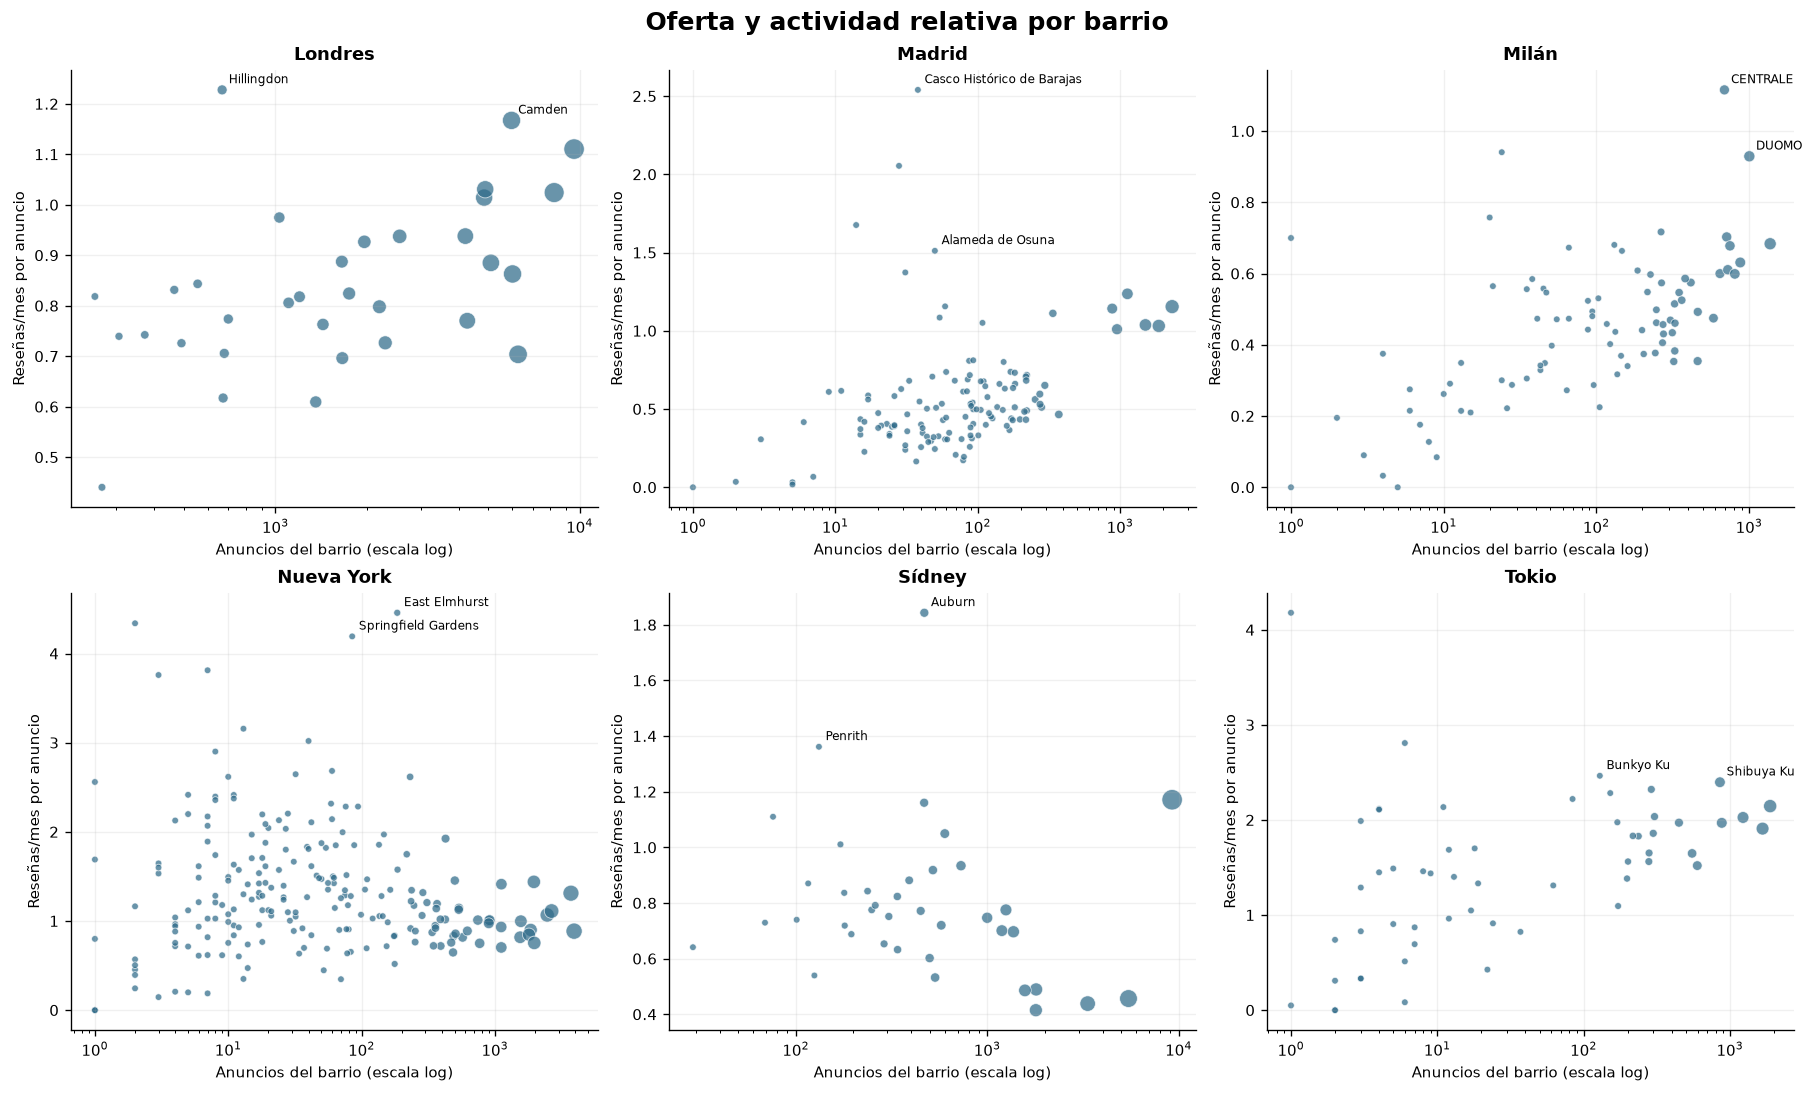

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for ax, (city_key, frame) in zip(axes.flat, neighborhood.groupby("city_key", sort=True)):
    ax.scatter(frame["listings"], frame["activity_per_listing"],
               s=np.clip(frame["listings"] ** 0.55, 16, 150), alpha=.72,
               color=COLORS["blue"], edgecolor="white", linewidth=.5)
    ax.set_xscale("log")
    ax.set_title(CITY_LABELS[city_key])
    ax.set_xlabel("Anuncios del barrio (escala log)")
    ax.set_ylabel("Reseñas/mes por anuncio")
    ax.grid(alpha=.18)
    eligible = frame[frame.listings >= MIN_LISTINGS_RANKING]
    for idx in eligible["activity_per_listing"].nlargest(2).index:
        point = frame.loc[idx]
        ax.annotate(point.neighborhood, (point.listings, point.activity_per_listing),
                    xytext=(4, 4), textcoords="offset points", fontsize=7)
fig.suptitle("Oferta y actividad relativa por barrio", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "01_supply_vs_activity_neighborhood.png", bbox_inches="tight")
plt.show()

**Hipótesis.** Los barrios con menor volumen de anuncios pueden mostrar mayor actividad media por anuncio, señal compatible con menor presión competitiva relativa.

**Conclusión esperada / criterio de lectura.** La hipótesis recibe apoyo si aparecen barrios con oferta baja o media y actividad alta. Un punto aislado con pocos anuncios se considera frágil; por eso las etiquetas exigen al menos 30 anuncios.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [4]:
eligible = neighborhood[neighborhood.listings >= MIN_LISTINGS_RANKING]
corr = eligible.groupby("city", observed=True).apply(
    lambda x: x[["listings", "activity_per_listing"]].corr(method="spearman").iloc[0, 1],
    include_groups=False,
).sort_values()
display(Markdown(
    "**Conclusión observada.** Las correlaciones de Spearman entre volumen y actividad por barrio "
    "van de **{:.2f}** ({}) a **{:.2f}** ({}). La relación no debe interpretarse como causal; "
    "el gráfico sirve para localizar excepciones dentro de cada ciudad.".format(
        corr.iloc[0], corr.index[0], corr.iloc[-1], corr.index[-1]
    )
))
display(corr.rename("rho_spearman").to_frame().style.format("{:.2f}"))

**Conclusión observada.** Las correlaciones de Spearman entre volumen y actividad por barrio van de **-0.33** (Nueva York) a **0.45** (Londres). La relación no debe interpretarse como causal; el gráfico sirve para localizar excepciones dentro de cada ciudad.

,rho_spearman
city,
Nueva York,-0.33
Sídney,-0.32
Tokio,0.25
Madrid,0.38
Milán,0.41
Londres,0.45


### Gráfico 2. Barrios con mayor y menor actividad relativa

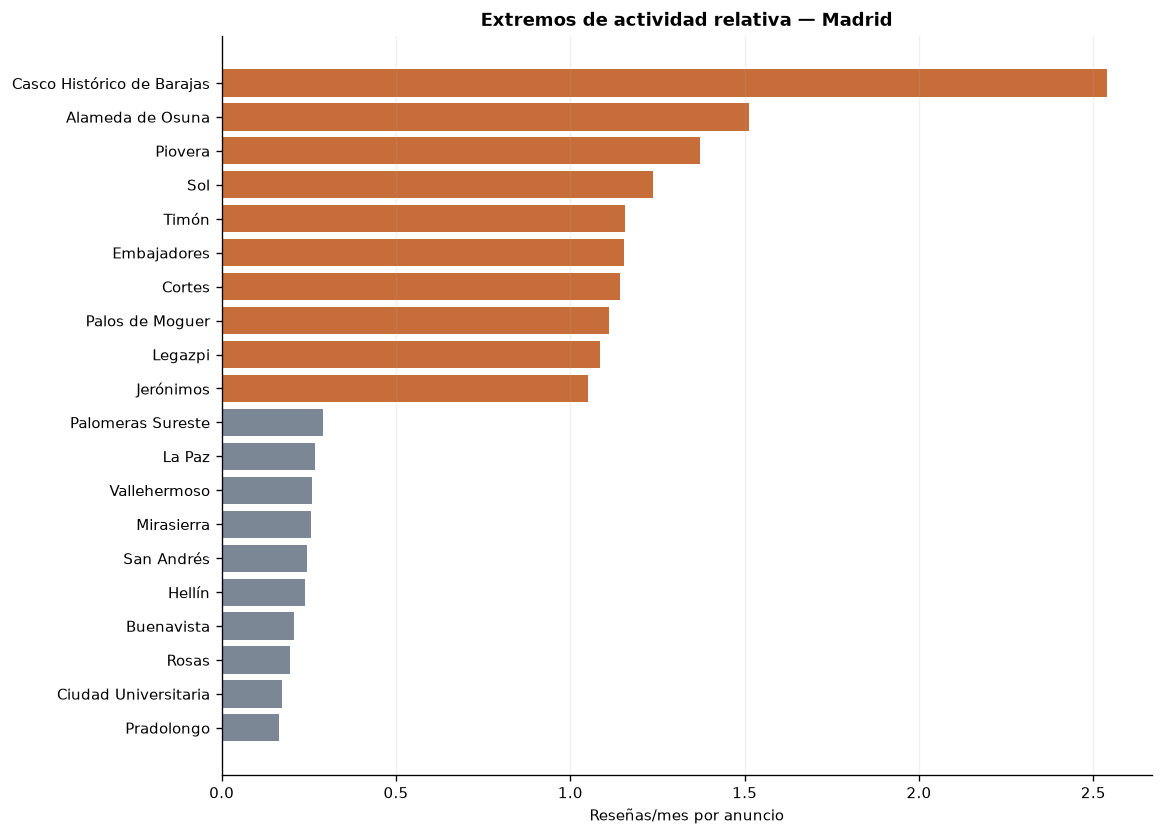

In [5]:
focus = neighborhood[(neighborhood.city_key == CITY_FOCUS) &
                     (neighborhood.listings >= MIN_LISTINGS_RANKING)].copy()
low = focus.nsmallest(10, "activity_per_listing").assign(grupo="10 menores")
high = focus.nlargest(10, "activity_per_listing").assign(grupo="10 mayores")
ranking = pd.concat([low, high]).sort_values("activity_per_listing")
colors = ranking["grupo"].map({"10 menores": COLORS["gray"], "10 mayores": COLORS["orange"]})

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ranking["neighborhood"], ranking["activity_per_listing"], color=colors)
ax.set_xlabel("Reseñas/mes por anuncio")
ax.set_title(f"Extremos de actividad relativa — {CITY_LABELS[CITY_FOCUS]}")
ax.grid(axis="x", alpha=.18)
fig.savefig(FIGURE_DIR / "02_neighborhood_activity_extremes.png", bbox_inches="tight")
plt.show()

all_rankings = neighborhood[neighborhood.listings >= MIN_LISTINGS_RANKING].copy()
all_rankings["rank_high"] = all_rankings.groupby("city")["activity_per_listing"].rank(method="first", ascending=False)
all_rankings["rank_low"] = all_rankings.groupby("city")["activity_per_listing"].rank(method="first", ascending=True)
all_rankings[(all_rankings.rank_high <= 10) | (all_rankings.rank_low <= 10)].to_csv(
    TABLE_DIR / "neighborhood_top_bottom_10_all_cities.csv", index=False
)

**Hipótesis.** Dentro de una misma ciudad existen diferencias materiales de actividad por anuncio entre barrios con una base mínima de oferta.

**Conclusión esperada / criterio de lectura.** Una separación amplia entre los extremos sugiere que el barrio aporta información adicional al volumen de oferta. Los extremos son candidatos a investigación comercial, no recomendaciones automáticas.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [6]:
gap = high.activity_per_listing.median() / low.activity_per_listing.median()
top = high.iloc[0]
bottom = low.iloc[0]
display(Markdown(
    f"**Conclusión observada.** En {CITY_LABELS[CITY_FOCUS]}, la mediana del grupo superior es "
    f"**{gap:.1f} veces** la mediana del inferior. {top.neighborhood} lidera entre barrios elegibles "
    f"con **{top.activity_per_listing:.2f}**, mientras {bottom.neighborhood} registra "
    f"**{bottom.activity_per_listing:.2f} reseñas/mes por anuncio**. Conviene revisar tipología, "
    f"estacionalidad y cobertura antes de actuar."
))

**Conclusión observada.** En Madrid, la mediana del grupo superior es **4.8 veces** la mediana del inferior. Casco Histórico de Barajas lidera entre barrios elegibles con **2.54**, mientras Pradolongo registra **0.17 reseñas/mes por anuncio**. Conviene revisar tipología, estacionalidad y cobertura antes de actuar.

### Gráfico 3. Mapa geográfico de actividad relativa

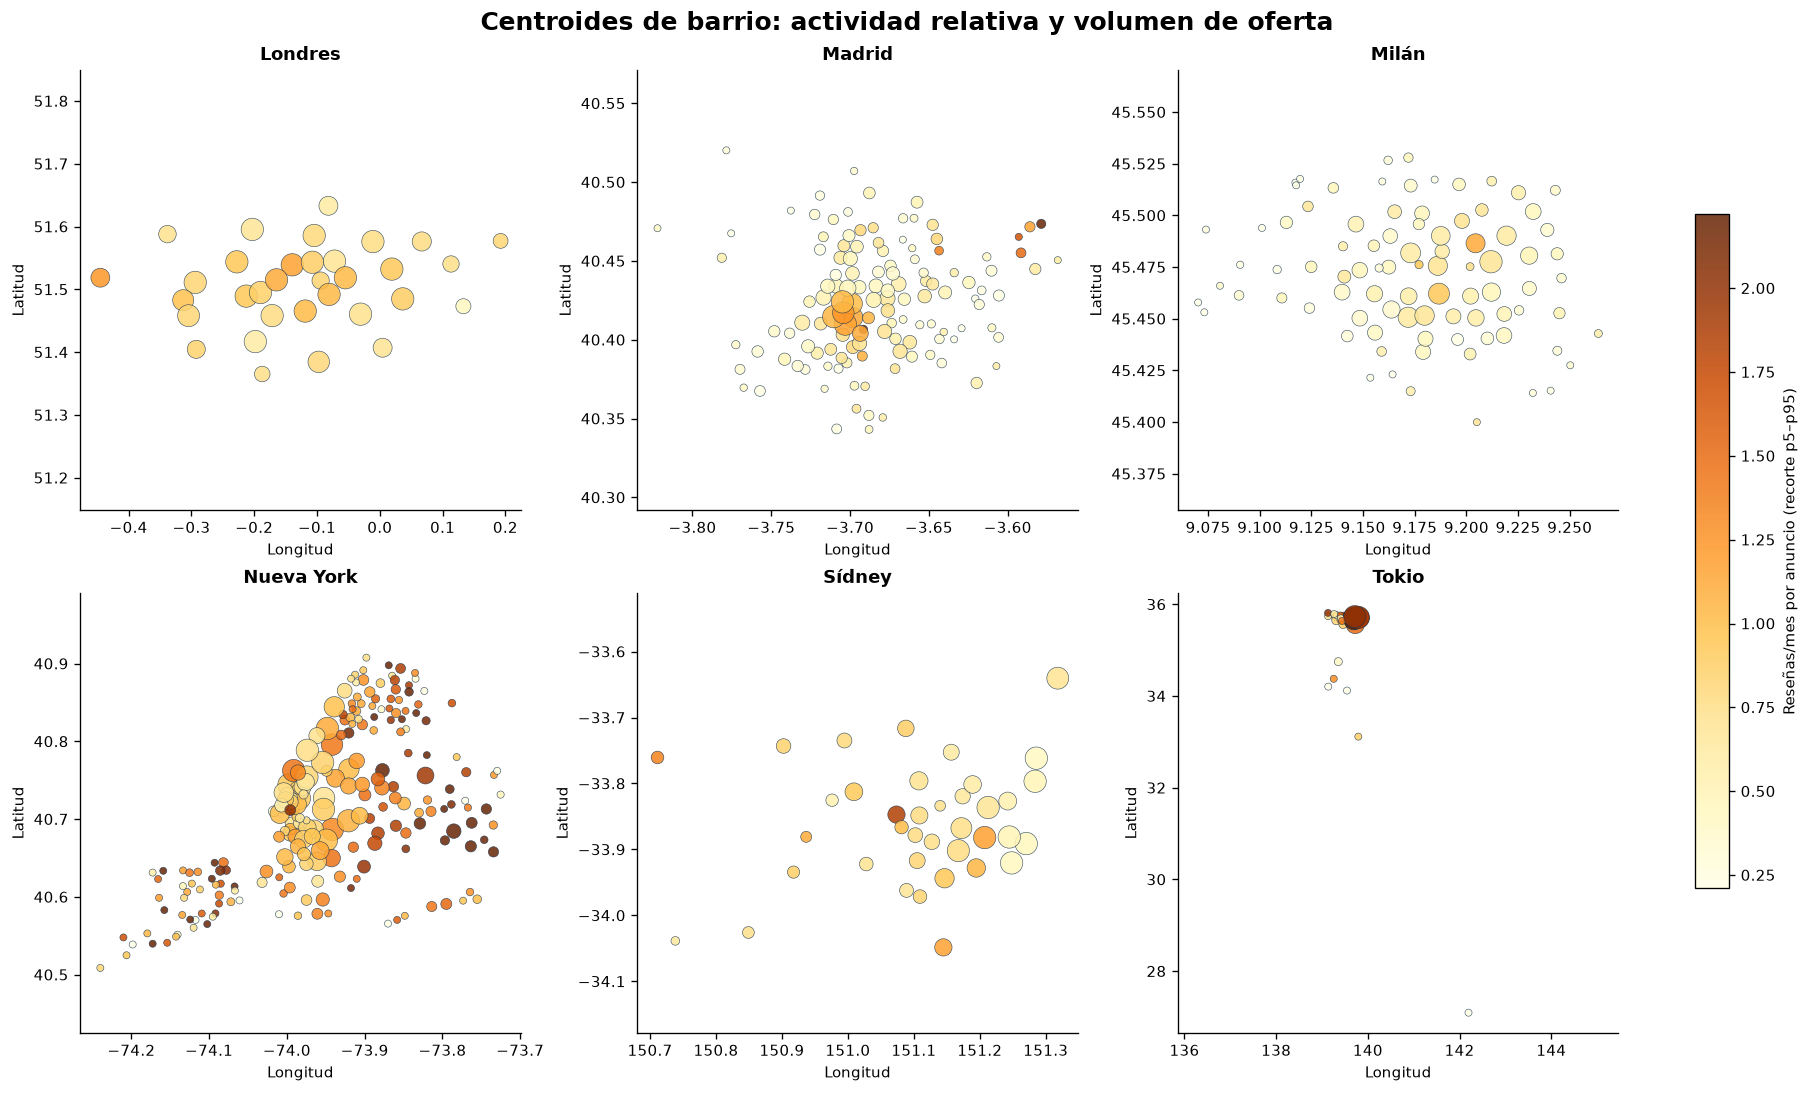

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
vmin, vmax = neighborhood.activity_per_listing.quantile([.05, .95])
for ax, (city_key, frame) in zip(axes.flat, neighborhood.groupby("city_key", sort=True)):
    scatter = ax.scatter(frame.longitude, frame.latitude,
                         c=frame.activity_per_listing.clip(vmin, vmax),
                         s=np.clip(np.sqrt(frame.listings) * 5, 18, 180),
                         cmap="YlOrBr", vmin=vmin, vmax=vmax,
                         edgecolor=COLORS["navy"], linewidth=.35, alpha=.85)
    ax.set_title(CITY_LABELS[city_key])
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_aspect("equal", adjustable="datalim")
fig.colorbar(scatter, ax=axes, shrink=.7, label="Reseñas/mes por anuncio (recorte p5–p95)")
fig.suptitle("Centroides de barrio: actividad relativa y volumen de oferta", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "03_geographic_activity_neighborhood.png", bbox_inches="tight")
plt.show()

**Hipótesis.** La actividad relativa no se distribuye uniformemente y puede formar zonas contiguas dentro de cada ciudad.

**Conclusión esperada / criterio de lectura.** Agrupaciones espaciales de tonos altos apoyarían una hipótesis territorial; puntos aislados requieren revisar tamaño muestral y límites del barrio. El mapa usa centroides medianos, no polígonos administrativos.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [8]:
city_spread = neighborhood.groupby("city", observed=True)["activity_per_listing"].agg(
    p10=lambda x: x.quantile(.10), p90=lambda x: x.quantile(.90)
)
city_spread["p90_p10_ratio"] = city_spread.p90 / city_spread.p10.replace(0, np.nan)
widest = city_spread.p90_p10_ratio.idxmax()
display(Markdown(
    f"**Conclusión observada.** {widest} muestra la mayor dispersión relativa entre percentiles "
    f"10 y 90 de barrio (**{city_spread.loc[widest, 'p90_p10_ratio']:.1f}×**). La variación espacial "
    f"justifica analizar barrios dentro de cada ciudad, aunque no demuestra por sí sola clústeres estadísticos."
))

**Conclusión observada.** Tokio muestra la mayor dispersión relativa entre percentiles 10 y 90 de barrio (**6.8×**). La variación espacial justifica analizar barrios dentro de cada ciudad, aunque no demuestra por sí sola clústeres estadísticos.

## 2. Concentración de actividad histórica

### Gráfico 4. Curvas de Pareto

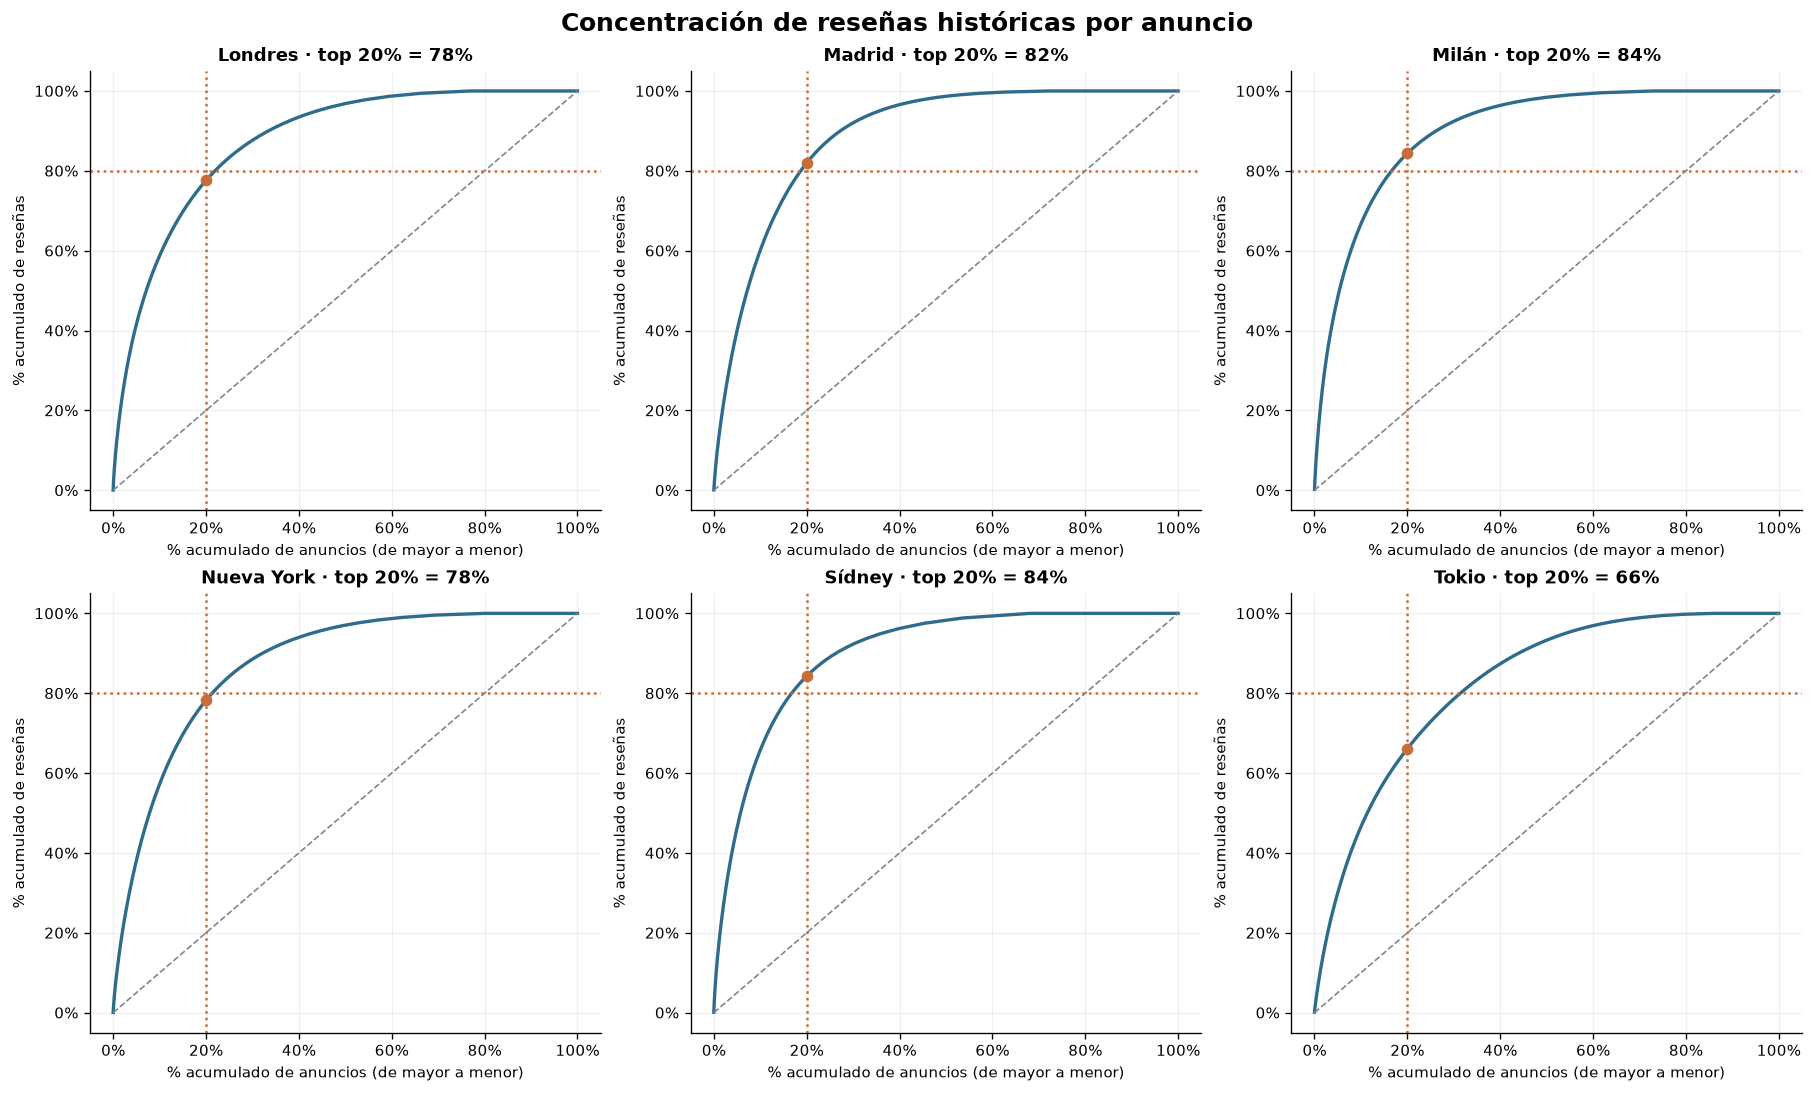

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
for ax, (city_key, frame) in zip(axes.flat, listings.groupby("city_key", sort=True)):
    values = frame.number_of_reviews.sort_values(ascending=False).to_numpy()
    cumulative = np.cumsum(values) / values.sum()
    x = np.arange(1, len(values)+1) / len(values)
    ax.plot(x, cumulative, color=COLORS["blue"], lw=2)
    ax.plot([0, 1], [0, 1], ls="--", color=COLORS["gray"], lw=1, label="Igualdad")
    ax.axvline(.20, color=COLORS["orange"], ls=":", lw=1.5)
    ax.axhline(.80, color=COLORS["orange"], ls=":", lw=1.5)
    metric = pareto_summary.loc[pareto_summary.city_key == city_key].iloc[0]
    ax.scatter(.20, metric.top20_review_share, color=COLORS["orange"], zorder=3)
    ax.set_title(f"{CITY_LABELS[city_key]} · top 20% = {metric.top20_review_share:.0%}")
    ax.set_xlabel("% acumulado de anuncios (de mayor a menor)")
    ax.set_ylabel("% acumulado de reseñas")
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=.18)
fig.suptitle("Concentración de reseñas históricas por anuncio", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "04_pareto_reviews.png", bbox_inches="tight")
plt.show()
pareto_summary.to_csv(TABLE_DIR / "pareto_summary_by_city.csv", index=False)

**Hipótesis.** Una minoría de anuncios concentra una parte desproporcionada de las reseñas históricas.

**Conclusión esperada / criterio de lectura.** La regla 80/20 se considera aproximada solo si el 20 % reúne cerca del 80 %. Se reportarán el porcentaje real concentrado por el top 20 % y la proporción de anuncios necesaria para alcanzar el 80 %.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [10]:
rows = []
for row in pareto_summary.sort_values("top20_review_share", ascending=False).itertuples():
    rows.append(f"- **{row.city}:** top 20 % = {row.top20_review_share:.1%}; "
                f"se necesita {row.listing_share_for_80:.1%} de anuncios para reunir el 80 %.")
display(Markdown("**Conclusión observada.** La concentración es elevada, pero el patrón real debe "
                 "expresarse con sus cifras, no llamarse automáticamente 80/20." +
                 chr(10) * 2 + chr(10).join(rows)))

**Conclusión observada.** La concentración es elevada, pero el patrón real debe expresarse con sus cifras, no llamarse automáticamente 80/20.

- **Milán:** top 20 % = 84.4%; se necesita 16.6% de anuncios para reunir el 80 %.
- **Sídney:** top 20 % = 84.3%; se necesita 16.8% de anuncios para reunir el 80 %.
- **Madrid:** top 20 % = 82.0%; se necesita 18.7% de anuncios para reunir el 80 %.
- **Nueva York:** top 20 % = 78.2%; se necesita 21.3% de anuncios para reunir el 80 %.
- **Londres:** top 20 % = 77.6%; se necesita 21.9% de anuncios para reunir el 80 %.
- **Tokio:** top 20 % = 66.1%; se necesita 31.4% de anuncios para reunir el 80 %.

### Gráfico 5. Distribución del número de reseñas

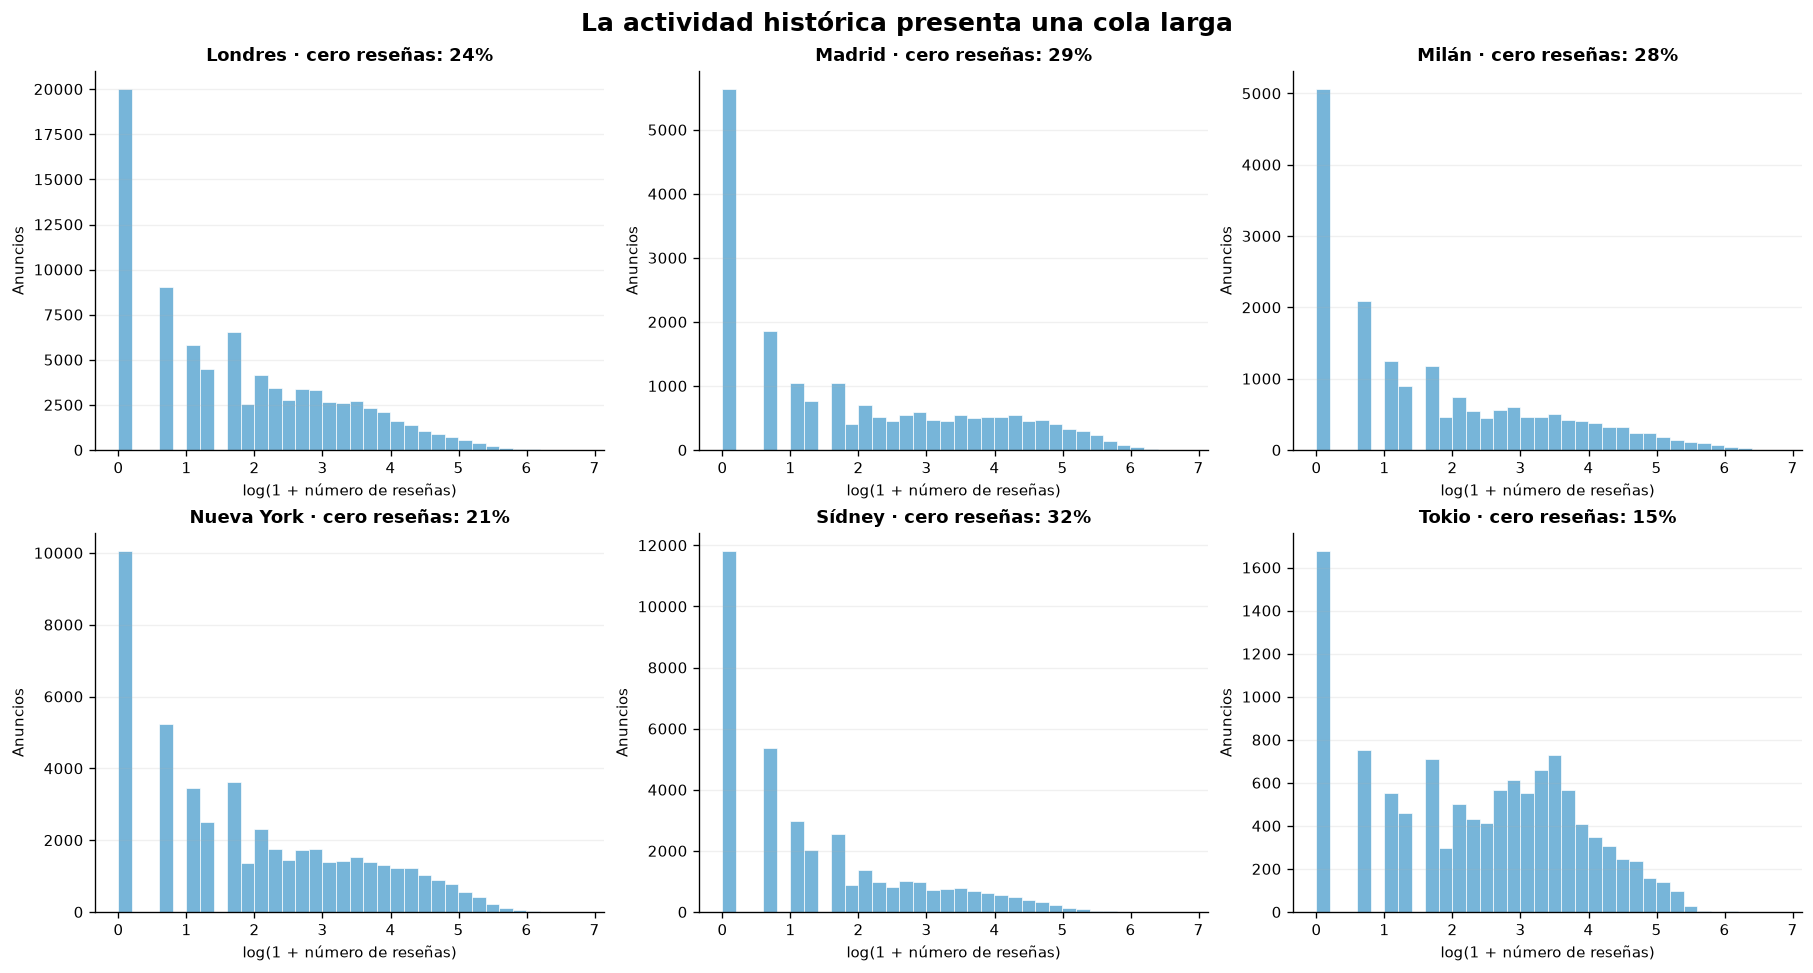

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
bins = np.linspace(0, np.log1p(listings.number_of_reviews.max()), 35)
for ax, (city_key, frame) in zip(axes.flat, listings.groupby("city_key", sort=True)):
    ax.hist(np.log1p(frame.number_of_reviews), bins=bins, color=COLORS["sky"],
            edgecolor="white", linewidth=.4)
    zero_share = frame.number_of_reviews.eq(0).mean()
    ax.set_title(f"{CITY_LABELS[city_key]} · cero reseñas: {zero_share:.0%}")
    ax.set_xlabel("log(1 + número de reseñas)")
    ax.set_ylabel("Anuncios")
    ax.grid(axis="y", alpha=.18)
fig.suptitle("La actividad histórica presenta una cola larga", fontsize=15, fontweight="bold")
fig.savefig(FIGURE_DIR / "05_reviews_histogram.png", bbox_inches="tight")
plt.show()

**Hipótesis.** La distribución de reseñas está muy sesgada a la derecha, con muchos anuncios sin reseñas y una cola pequeña de anuncios muy reseñados.

**Conclusión esperada / criterio de lectura.** La hipótesis se apoya si la masa se concentra cerca de cero incluso tras transformar el eje con log(1+x). Esto explicaría la separación de las curvas de Pareto respecto a la igualdad.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [12]:
distribution = listings.groupby("city", observed=True).number_of_reviews.agg(
    zero_share=lambda x: x.eq(0).mean(), median="median", p95=lambda x: x.quantile(.95), maximum="max"
).sort_values("zero_share", ascending=False)
display(Markdown(
    f"**Conclusión observada.** La proporción sin reseñas va de "
    f"**{distribution.zero_share.min():.1%}** a **{distribution.zero_share.max():.1%}** según ciudad. "
    f"La distancia entre mediana, percentil 95 y máximo confirma una cola larga; la media sola sería "
    f"una descripción incompleta."
))
display(distribution.style.format({"zero_share": "{:.1%}", "median": "{:.0f}", "p95": "{:.0f}", "maximum": "{:.0f}"}))

**Conclusión observada.** La proporción sin reseñas va de **14.6%** a **32.2%** según ciudad. La distancia entre mediana, percentil 95 y máximo confirma una cola larga; la media sola sería una descripción incompleta.

,zero_share,median,p95,maximum
city,,,,
Sídney,32.2%,2,64,493
Madrid,28.7%,4,164,706
Milán,27.6%,3,120,896
Londres,23.5%,4,79,716
Nueva York,20.6%,5,114,629
Tokio,14.6%,12,107,453


## 3. Tamaño de cartera observado del anfitrión

### Gráfico 6. Porcentaje de anuncios por grupo de cartera

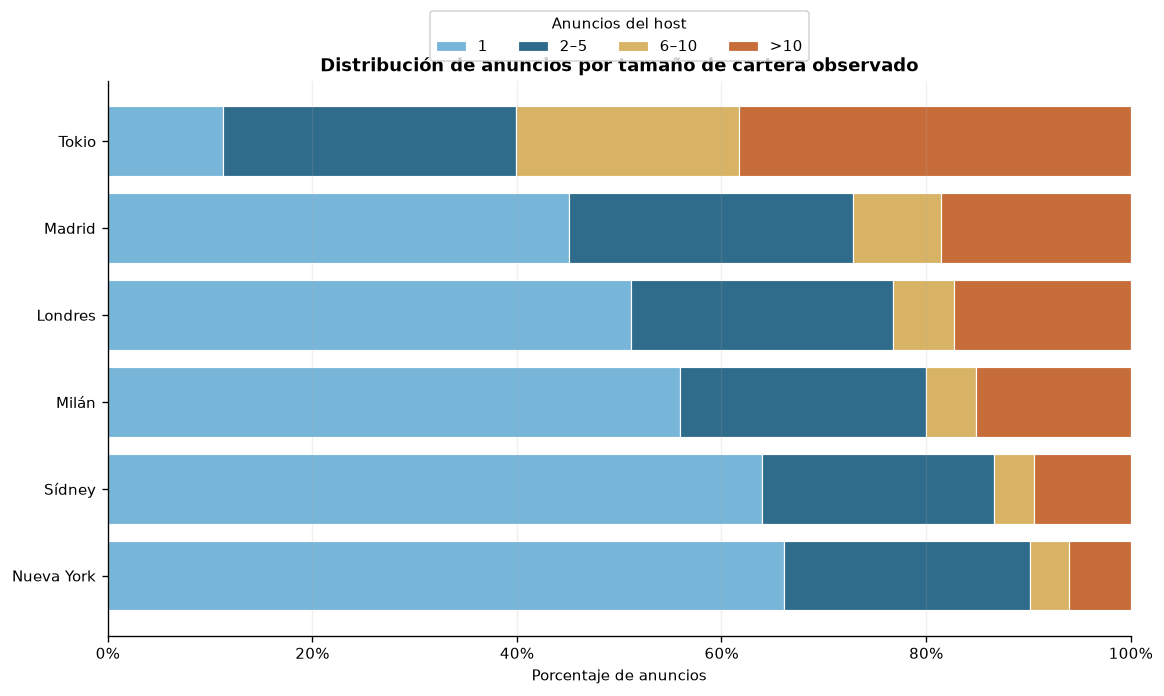

In [13]:
listing_mix = listing_mix.sort_values(">10")
fig, ax = plt.subplots(figsize=(11, 6))
left = np.zeros(len(listing_mix))
palette = [COLORS["sky"], COLORS["blue"], COLORS["sand"], COLORS["orange"]]
for bucket, color in zip(PORTFOLIO_ORDER, palette):
    ax.barh(listing_mix.index, listing_mix[bucket], left=left, label=bucket,
            color=color, edgecolor="white", linewidth=.7)
    left += listing_mix[bucket].to_numpy()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Porcentaje de anuncios")
ax.set_title("Distribución de anuncios por tamaño de cartera observado")
ax.legend(title="Anuncios del host", ncol=4, bbox_to_anchor=(.5, 1.14), loc="upper center")
ax.grid(axis="x", alpha=.18)
fig.savefig(FIGURE_DIR / "06_listing_share_by_portfolio.png", bbox_inches="tight")
plt.show()
listing_mix.to_csv(TABLE_DIR / "listing_share_by_portfolio.csv")

**Hipótesis.** La oferta de algunas ciudades está más concentrada en anfitriones con carteras grandes.

**Conclusión esperada / criterio de lectura.** Una mayor proporción en 6–10 y >10 indica más anuncios vinculados a carteras amplias dentro del snapshot. No identifica propiedad, empresa, profesionalidad ni estatus fiscal.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [14]:
gt5 = (listing_mix["6–10"] + listing_mix[">10"]).sort_values(ascending=False)
display(Markdown(
    f"**Conclusión observada.** La cuota de anuncios en carteras de más de cinco oscila entre "
    f"**{gt5.iloc[-1]:.1%}** ({gt5.index[-1]}) y **{gt5.iloc[0]:.1%}** ({gt5.index[0]}). "
    f"Esto describe concentración operativa observada, no la condición profesional del host."
))

**Conclusión observada.** La cuota de anuncios en carteras de más de cinco oscila entre **9.8%** (Nueva York) y **60.1%** (Tokio). Esto describe concentración operativa observada, no la condición profesional del host.

### Gráfico 7. Porcentaje de anfitriones por grupo de cartera

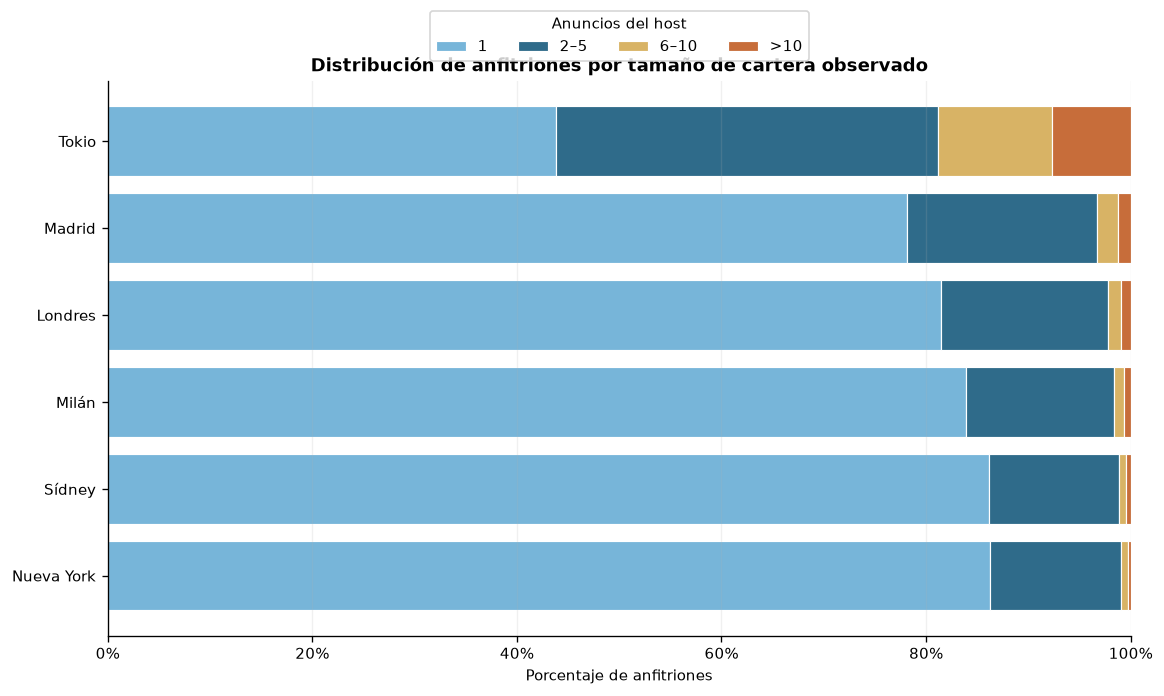

In [15]:
host_mix = host_mix.loc[listing_mix.index]
fig, ax = plt.subplots(figsize=(11, 6))
left = np.zeros(len(host_mix))
for bucket, color in zip(PORTFOLIO_ORDER, palette):
    ax.barh(host_mix.index, host_mix[bucket], left=left, label=bucket,
            color=color, edgecolor="white", linewidth=.7)
    left += host_mix[bucket].to_numpy()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Porcentaje de anfitriones")
ax.set_title("Distribución de anfitriones por tamaño de cartera observado")
ax.legend(title="Anuncios del host", ncol=4, bbox_to_anchor=(.5, 1.14), loc="upper center")
ax.grid(axis="x", alpha=.18)
fig.savefig(FIGURE_DIR / "07_host_share_by_portfolio.png", bbox_inches="tight")
plt.show()
host_mix.to_csv(TABLE_DIR / "host_share_by_portfolio.csv")

**Hipótesis.** Los anfitriones individuales pueden ser mayoría aunque una fracción pequeña de anfitriones con carteras amplias gestione una cuota relevante de anuncios.

**Conclusión esperada / criterio de lectura.** La diferencia entre el porcentaje de hosts y el porcentaje de listings revela el efecto de escala: pocos hosts pueden representar muchos anuncios.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [16]:
host_gt5 = (host_mix["6–10"] + host_mix[">10"])
amplification = (gt5 / host_gt5).sort_values(ascending=False)
leader = amplification.index[0]
display(Markdown(
    f"**Conclusión observada.** En todas las ciudades, la cuota de anuncios de carteras >5 supera "
    f"su cuota de anfitriones. La mayor amplificación aparece en **{leader}**: la participación en "
    f"anuncios es **{amplification.iloc[0]:.1f} veces** su participación entre hosts."
))

**Conclusión observada.** En todas las ciudades, la cuota de anuncios de carteras >5 supera su cuota de anfitriones. La mayor amplificación aparece en **Milán**: la participación en anuncios es **12.2 veces** su participación entre hosts.

## 4. Síntesis comparativa entre ciudades

### Gráfico 8. Actividad relativa media por ciudad

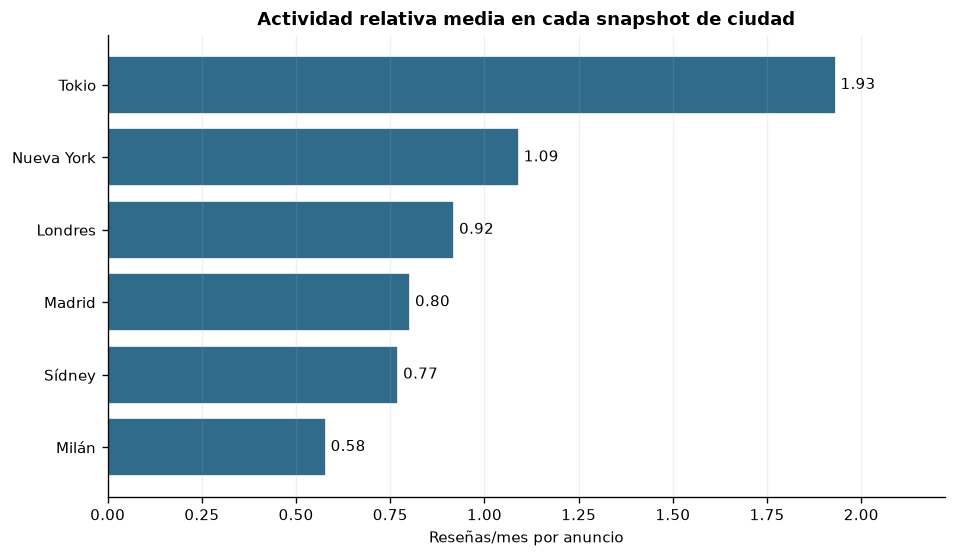

In [17]:
activity_city = city_summary.sort_values("activity_per_listing")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(activity_city.city, activity_city.activity_per_listing,
               color=COLORS["blue"], edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlim(0, activity_city.activity_per_listing.max() * 1.15)
ax.set_xlabel("Reseñas/mes por anuncio")
ax.set_title("Actividad relativa media en cada snapshot de ciudad")
ax.grid(axis="x", alpha=.18)
fig.savefig(FIGURE_DIR / "08_city_activity.png", bbox_inches="tight")
plt.show()

**Hipótesis.** Las ciudades difieren en actividad mensual media por anuncio.

**Conclusión esperada / criterio de lectura.** Las diferencias pueden servir para contextualizar los barrios, pero no forman un ranking contemporáneo porque las fechas de extracción no están confirmadas y las exposiciones pueden ser distintas.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [18]:
highest = activity_city.iloc[-1]
lowest = activity_city.iloc[0]
display(Markdown(
    f"**Conclusión observada.** {highest.city} registra **{highest.activity_per_listing:.2f}** frente a "
    f"**{lowest.activity_per_listing:.2f}** en {lowest.city}, una razón de **{highest.activity_per_listing/lowest.activity_per_listing:.1f}×**. "
    f"La señal es descriptiva y requiere snapshots comparables antes de orientar inversión entre ciudades."
))

**Conclusión observada.** Tokio registra **1.93** frente a **0.58** en Milán, una razón de **3.3×**. La señal es descriptiva y requiere snapshots comparables antes de orientar inversión entre ciudades.

### Gráfico 9. Concentración histórica frente a carteras amplias

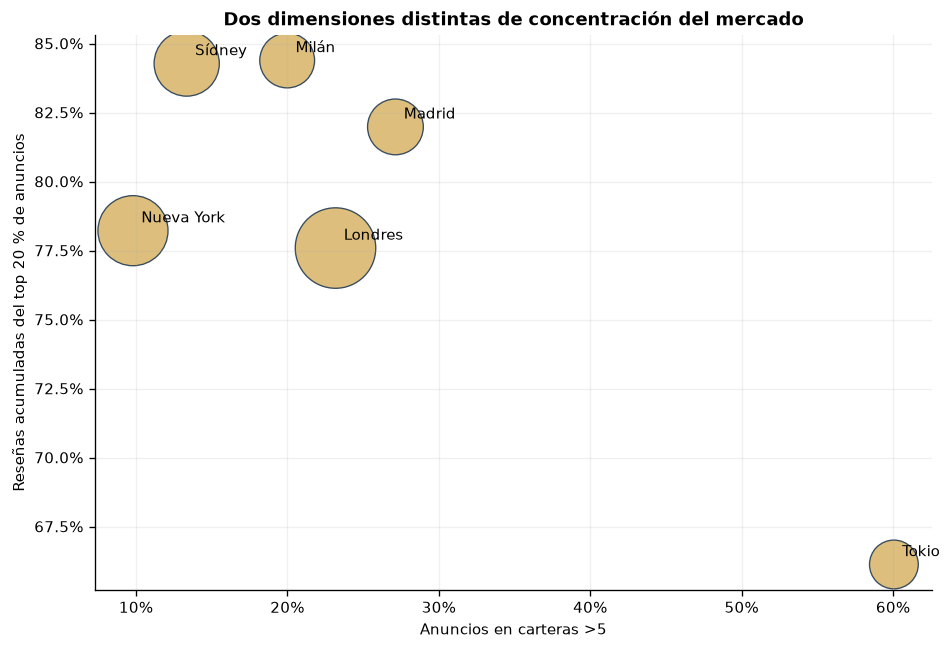

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(city_summary.listings_hosts_gt5, city_summary.top20_review_share,
           s=np.sqrt(city_summary.listings) * 8, color=COLORS["sand"],
           edgecolor=COLORS["navy"], linewidth=.8, alpha=.85)
for row in city_summary.itertuples():
    ax.annotate(row.city, (row.listings_hosts_gt5, row.top20_review_share),
                xytext=(5, 5), textcoords="offset points")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Anuncios en carteras >5")
ax.set_ylabel("Reseñas acumuladas del top 20 % de anuncios")
ax.set_title("Dos dimensiones distintas de concentración del mercado")
ax.grid(alpha=.18)
fig.savefig(FIGURE_DIR / "09_concentration_comparison.png", bbox_inches="tight")
plt.show()

**Hipótesis.** Las ciudades con mayor presencia de carteras amplias podrían mostrar también mayor concentración de reseñas en pocos anuncios.

**Conclusión esperada / criterio de lectura.** Una pendiente ascendente sería consistente con asociación entre ambas dimensiones. Con solo seis observaciones, el gráfico es exploratorio y no permite inferencia robusta ni causalidad.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [20]:
rho = city_summary[["listings_hosts_gt5", "top20_review_share"]].corr(method="spearman").iloc[0, 1]
display(Markdown(
    f"**Conclusión observada.** La correlación de Spearman entre ambas métricas es **{rho:.2f}** "
    f"en seis ciudades. Se presenta como señal exploratoria; el tamaño muestral y la falta de "
    f"alineación temporal impiden convertirla en relación general."
))

**Conclusión observada.** La correlación de Spearman entre ambas métricas es **-0.49** en seis ciudades. Se presenta como señal exploratoria; el tamaño muestral y la falta de alineación temporal impiden convertirla en relación general.

### Gráfico 10. Dispersión geográfica de la oferta

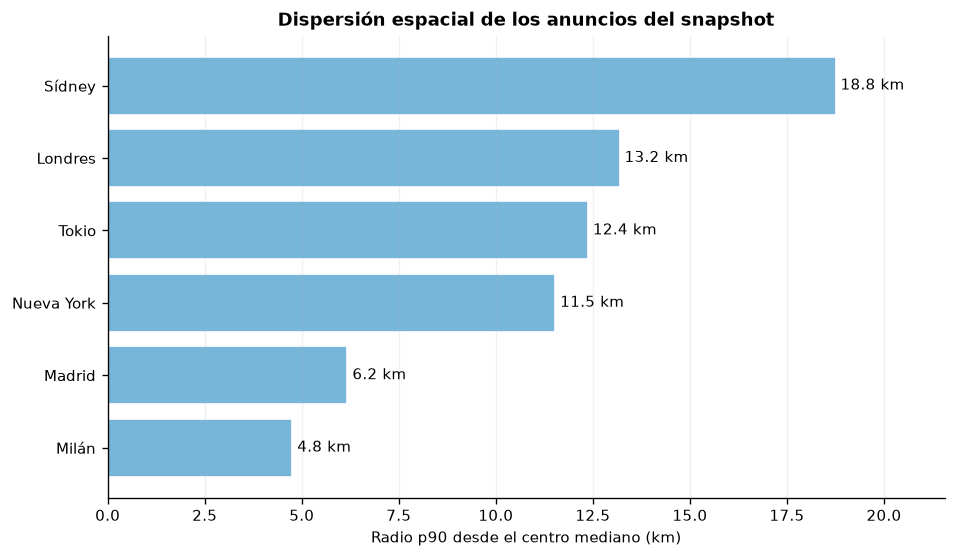

In [21]:
dispersion = city_summary.sort_values("radius_p90_km")
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(dispersion.city, dispersion.radius_p90_km, color=COLORS["sky"], edgecolor="white")
ax.bar_label(bars, fmt="%.1f km", padding=3)
ax.set_xlim(0, dispersion.radius_p90_km.max() * 1.15)
ax.set_xlabel("Radio p90 desde el centro mediano (km)")
ax.set_title("Dispersión espacial de los anuncios del snapshot")
ax.grid(axis="x", alpha=.18)
fig.savefig(FIGURE_DIR / "10_city_geographic_dispersion.png", bbox_inches="tight")
plt.show()
city_summary.to_csv(TABLE_DIR / "city_summary.csv", index=False)

**Hipótesis.** La oferta de algunas ciudades está geográficamente más dispersa, lo que puede exigir segmentación comercial y operativa distinta.

**Conclusión esperada / criterio de lectura.** Un radio p90 mayor indica que los anuncios se extienden más desde el centro mediano del snapshot. El indicador depende de la cobertura territorial de cada archivo y no equivale al tamaño oficial de la ciudad.

La celda siguiente genera la **conclusión observada** con los datos ejecutados. La expectativa no se presenta como resultado.

In [22]:
wide = dispersion.iloc[-1]
compact = dispersion.iloc[0]
display(Markdown(
    f"**Conclusión observada.** El radio p90 va de **{compact.radius_p90_km:.1f} km** en "
    f"{compact.city} a **{wide.radius_p90_km:.1f} km** en {wide.city}. Esto sugiere necesidades "
    f"distintas de cobertura territorial, sujetas a validar el alcance geográfico de cada fuente."
))

**Conclusión observada.** El radio p90 va de **4.8 km** en Milán a **18.8 km** en Sídney. Esto sugiere necesidades distintas de cobertura territorial, sujetas a validar el alcance geográfico de cada fuente.

## Insights de negocio

La celda siguiente traduce los resultados a decisiones posibles. Son líneas de investigación y priorización, no órdenes automáticas de captación.

In [23]:
eligible = neighborhood[neighborhood.listings >= MIN_LISTINGS_RANKING].copy()
opportunities = eligible.sort_values(["city", "activity_per_listing"], ascending=[True, False]).groupby(
    "city", observed=True
).head(3)
opportunity_lines = [
    f"- **{city}:** investigar primero " + ", ".join(
        f"{r.neighborhood} ({r.activity_per_listing:.2f} reseñas/mes por anuncio; n={r.listings})"
        for r in group.itertuples()
    )
    for city, group in opportunities.groupby("city", observed=True)
]

display(Markdown(
    '''### 1. Priorizar investigación comercial por barrio

Los barrios con actividad relativa alta y al menos 30 anuncios ofrecen una primera lista verificable. Antes de captar oferta, habría que contrastar estacionalidad, tipo de alojamiento, regulación y capacidad operativa.

''' + chr(10).join(opportunity_lines) +
    '''

### 2. Diseñar estrategias distintas para la cabeza y la cola

La concentración de reseñas indica que una parte pequeña del inventario acumula gran parte de la actividad histórica. La propuesta comercial puede separar anuncios consolidados, donde importa retención y servicio, de la cola con poca o ninguna reseña, donde importa activación, calidad de ficha y diagnóstico de falta de tracción.

### 3. Segmentar anfitriones por complejidad de cartera

La diferencia entre cuota de hosts y cuota de listings justifica ofertas diferenciadas: autoservicio para carteras individuales, automatización para 2–5 y gestión de operaciones e integración para carteras superiores. Los buckets miden escala observada y no estatus profesional.

### 4. Ajustar cobertura operativa a la dispersión territorial

Las ciudades con mayor radio p90 pueden requerir equipos, proveedores o campañas distribuidas geográficamente. En mercados compactos puede ser viable concentrar operaciones en menos zonas.

### 5. No comparar precios hasta completar el manifiesto

La relación entre cartera y precio queda fuera del análisis principal hasta confirmar moneda y fecha de extracción. También se necesitan snapshots repetidos para hablar de evolución temporal.
'''
))

opportunities.to_csv(TABLE_DIR / "neighborhood_research_shortlist.csv", index=False)

### 1. Priorizar investigación comercial por barrio

Los barrios con actividad relativa alta y al menos 30 anuncios ofrecen una primera lista verificable. Antes de captar oferta, habría que contrastar estacionalidad, tipo de alojamiento, regulación y capacidad operativa.

- **Londres:** investigar primero Hillingdon (1.23 reseñas/mes por anuncio; n=668), Camden (1.17 reseñas/mes por anuncio; n=5972), Westminster (1.11 reseñas/mes por anuncio; n=9588)
- **Madrid:** investigar primero Casco Histórico de Barajas (2.54 reseñas/mes por anuncio; n=38), Alameda de Osuna (1.51 reseñas/mes por anuncio; n=50), Piovera (1.37 reseñas/mes por anuncio; n=31)
- **Milán:** investigar primero CENTRALE (1.12 reseñas/mes por anuncio; n=689), DUOMO (0.93 reseñas/mes por anuncio; n=1003), MACIACHINI - MAGGIOLINA (0.72 reseñas/mes por anuncio; n=265)
- **Nueva York:** investigar primero East Elmhurst (4.46 reseñas/mes por anuncio; n=185), Springfield Gardens (4.19 reseñas/mes por anuncio; n=85), South Ozone Park (3.02 reseñas/mes por anuncio; n=40)
- **Sídney:** investigar primero Auburn (1.84 reseñas/mes por anuncio; n=469), Penrith (1.36 reseñas/mes por anuncio; n=132), Sydney (1.17 reseñas/mes por anuncio; n=9241)
- **Tokio:** investigar primero Bunkyo Ku (2.47 reseñas/mes por anuncio; n=129), Shibuya Ku (2.40 reseñas/mes por anuncio; n=854), Nakano Ku (2.32 reseñas/mes por anuncio; n=290)

### 2. Diseñar estrategias distintas para la cabeza y la cola

La concentración de reseñas indica que una parte pequeña del inventario acumula gran parte de la actividad histórica. La propuesta comercial puede separar anuncios consolidados, donde importa retención y servicio, de la cola con poca o ninguna reseña, donde importa activación, calidad de ficha y diagnóstico de falta de tracción.

### 3. Segmentar anfitriones por complejidad de cartera

La diferencia entre cuota de hosts y cuota de listings justifica ofertas diferenciadas: autoservicio para carteras individuales, automatización para 2–5 y gestión de operaciones e integración para carteras superiores. Los buckets miden escala observada y no estatus profesional.

### 4. Ajustar cobertura operativa a la dispersión territorial

Las ciudades con mayor radio p90 pueden requerir equipos, proveedores o campañas distribuidas geográficamente. En mercados compactos puede ser viable concentrar operaciones en menos zonas.

### 5. No comparar precios hasta completar el manifiesto

La relación entre cartera y precio queda fuera del análisis principal hasta confirmar moneda y fecha de extracción. También se necesitan snapshots repetidos para hablar de evolución temporal.


## Takeaways y próximos pasos

- Los resultados permiten **priorizar dónde investigar**, medir concentración y adaptar propuestas por tamaño de cartera.
- Las conclusiones entre barrios son más defendibles dentro de una ciudad que entre ciudades.
- Antes de una decisión de inversión se deben confirmar fecha, procedencia, cobertura territorial y comparabilidad de los snapshots.
- Para estudiar evolución se necesitan varias capturas de la misma ciudad con fechas verificadas.

**Artefactos reutilizables:** el notebook exporta PNG a `artifacts/figures/market_structure_eda/` y CSV a `artifacts/tables/market_structure_eda/`.